# Analisi dell'errore sulla predizione di immagini

In [76]:
# COMMON LIBRARIES
import os
import cv2
import requests
import json
import numpy as np
import torch
import random

import matplotlib.pyplot as plt
from datetime import datetime

# DATA SET PREPARATION AND LOADING
from detectron2.data.datasets import register_coco_instances
from detectron2.data import DatasetCatalog, MetadataCatalog

# VISUALIZATION
from detectron2.utils.visualizer import Visualizer
from detectron2.utils.visualizer import ColorMode

# CONFIGURATION
from detectron2 import model_zoo
from detectron2.config import get_cfg

# EVALUATION
from detectron2.engine import DefaultPredictor

# TRAINING
from detectron2.engine import DefaultTrainer

Dati globali

In [77]:
# Percorsi ai file COCO
base_path = os.getcwd()

# Costruisci i percorsi relativi alla posizione dello script
json_file = os.path.join(base_path, "../../annotations", "instances_val2017.json")
image_folder = os.path.join(base_path, "../../val2017/")

# Nome dell'immagine di cui trovare la bounding box
image_filenames = ["000000409475.jpg", "000000000872.jpg", "000000002153.jpg"]  # Sostituisci con il nome dell'immagine desiderata

#Modello pre-addestrato
MODEL_USED = "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"

### Estrapolazione dei dati
Estraggo dal json delle annotazioni le informazioni relative alle bounding boxe delle immagini da predire

dati: [x_min, y_min, width, height]

In [78]:
def extract_pixels_from_coco(image_filename, json_file):
    # 1. Caricare il file JSON con le annotazioni
    with open(json_file, "r") as f:
        coco_data = json.load(f)

    # 2. Creare una mappatura tra category_id e category_name
    category_dict = {category["id"]: category["name"] for category in coco_data["categories"]}

    # 3. Trovare i dati dell'immagine corrispondente al nome file
    image_data = next((img for img in coco_data["images"] if img["file_name"] == image_filename), None)

    if image_data is None:
        print("Immagine non trovata nel dataset COCO!")
        return []

    image_id = image_data["id"]
    image_width = image_data["width"]
    image_height = image_data["height"]

    # 4. Estrarre le segmentazioni associate a questa immagine
    extracted_data = []
    for ann in coco_data["annotations"]:
        if ann["image_id"] == image_id:
            category_id = ann["category_id"]
            category_name = category_dict.get(category_id, "Unknown")

            # Converte le segmentazioni in array di interi (ogni istanza può avere più poligoni)
            segmentation_pixels = [np.array(seg, dtype=np.int32).reshape((-1, 2)).tolist() for seg in ann["segmentation"]]

            extracted_data.append({
                "category_name": category_name,
                "pixels": segmentation_pixels,
                "image_width": image_width,
                "image_height": image_height
            })

    return extracted_data


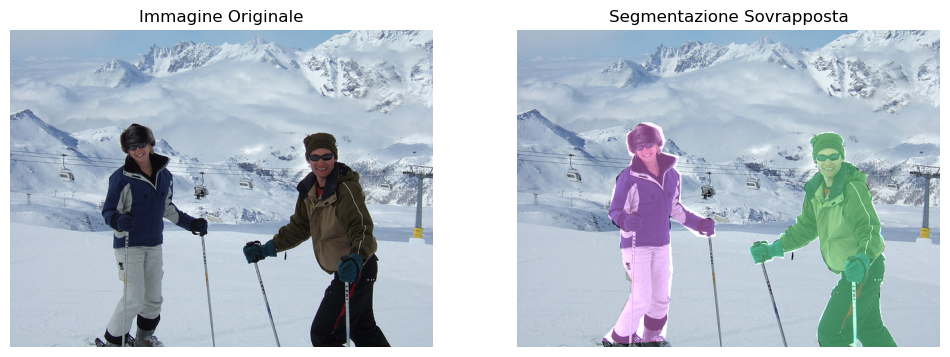

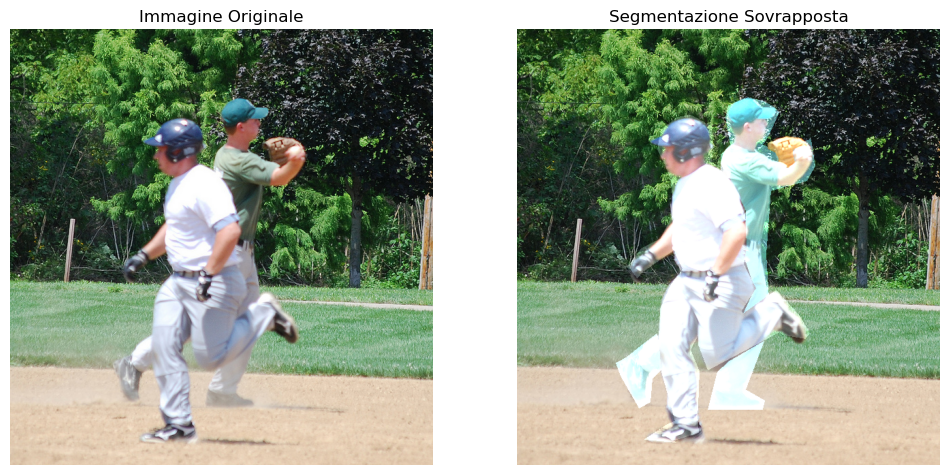

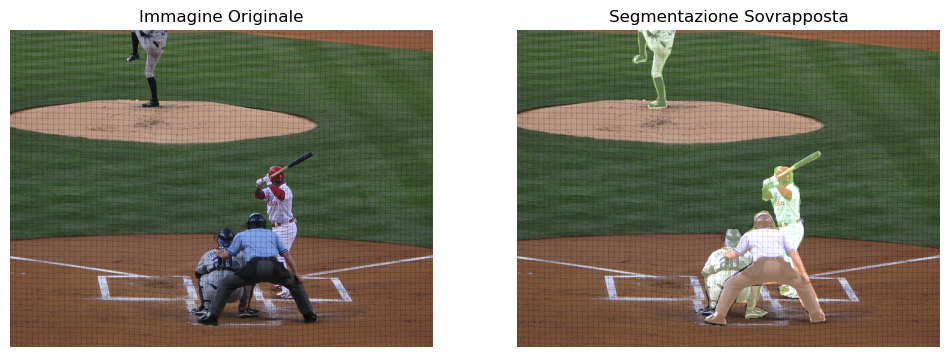

[{'category_name': 'person', 'pixels': [[[148, 447], [168, 409], [173, 396], [173, 378], [161, 356], [156, 318], [156, 299], [138, 283], [145, 243], [155, 219], [169, 207], [175, 192], [170, 190], [165, 172], [166, 157], [180, 148], [189, 141], [203, 141], [218, 149], [224, 169], [218, 185], [245, 192], [239, 210], [248, 218], [247, 263], [285, 285], [297, 289], [300, 312], [290, 314], [273, 313], [229, 279], [235, 364], [224, 465], [220, 470], [162, 474], [127, 470]]], 'image_width': 640, 'image_height': 480}
 {'category_name': 'person', 'pixels': [[[434, 238], [440, 229], [454, 217], [459, 214], [454, 206], [454, 201], [448, 198], [446, 190], [448, 184], [445, 172], [443, 165], [452, 160], [462, 156], [476, 155], [488, 160], [494, 167], [492, 174], [495, 181], [496, 189], [494, 201], [502, 200], [512, 206], [514, 212], [523, 216], [529, 220], [527, 229], [528, 235], [531, 242], [538, 255], [537, 260], [547, 286], [550, 301], [549, 309], [553, 313], [555, 323], [553, 334], [551, 336],

In [79]:
gt_instances = np.array([])
for file_name in image_filenames:
    # Estrarre i dati delle istanze segmentate
    instances = extract_pixels_from_coco(file_name, json_file)
    gt_instances = np.append(gt_instances, instances)
    # Visualizzare la segmentazione
    visualize_masks_on_image(file_name, instances, image_folder)

print(gt_instances)

In [80]:
def extract_polygons_from_masks(masks):
    """
    Converte le maschere binarie in poligoni (segmentazioni precise).
    """
    polygons = []
    for mask in masks:
        # Trova i contorni della maschera binaria (maschera di 1s e 0s)
        contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            # Appiattire il contorno in una lista di punti (x, y)
            polygon = contour.reshape(-1, 2).tolist()
            polygons.append(polygon)
    return polygons

def process_detectron2_output(image_filename, image_folder, model_used):
    # 1. Caricare l'immagine
    image = cv2.imread(image_folder + image_filename)
    
    # 2. Configurare il modello pre-addestrato di Detectron2
    cfg = get_cfg()
    cfg.merge_from_file(model_zoo.get_config_file(model_used))
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # Imposta la soglia di confidenza
    cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(model_used)
    cfg.MODEL.DEVICE = "cpu"  # Usa la CPU (puoi cambiare con 'cuda' se hai una GPU)
    
    # 3. Inizializzare il predittore
    predictor = DefaultPredictor(cfg)
    
    # 4. Eseguire il modello sull'immagine
    outputs = predictor(image)
    
    # 5. Estrarre le istanze predette (classi, bounding boxes)
    instances = outputs["instances"].to("cpu")
    
    # 6. Ottenere il metadata (nomi delle classi)
    metadata = MetadataCatalog.get(cfg.DATASETS.TRAIN[0])
    
    # 7. Estrazione delle informazioni delle classi, bounding boxes e maschere
    category_ids = instances.pred_classes.numpy()  # ID delle classi
    bboxes = instances.pred_boxes.tensor.numpy()  # Bounding boxes
    masks = instances.pred_masks.numpy()  # Maschere binarie per ogni istanza
    
    # 8. Creare un array delle istanze predette con le informazioni desiderate
    boxes_predected = []
    
    for category_id, bbox, mask in zip(category_ids, bboxes, masks):
        category_name = metadata.thing_classes[category_id]  # Ottieni il nome della categoria
        segmentation_pixels = extract_polygons_from_masks([mask])  # Poligoni precisi
        
        # Aggiungi l'istanza al risultato
        boxes_predected.append({
            "category_name": category_name,
            "pixels": segmentation_pixels,
            "image_width": image.shape[1],
            "image_height": image.shape[0]
        })

    # 9. Mostrare il risultato: maschere sovrapposte sull'immagine
    visualizer = Visualizer(image[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)
    out = visualizer.draw_instance_predictions(instances)
    
    # Convertire l'immagine da BGR a RGB
    image_result = out.get_image()[:, :, ::-1]
    
    # Mostrare l'immagine con Matplotlib
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image[:, :, ::-1])
    plt.title("Immagine Originale")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(image_result)
    plt.title("Immagine con Maschere")
    plt.axis("off")
    
    plt.show()

    # Stampare le istanze predette
    for entry in boxes_predected:
        print(entry)
    return boxes_predected

### Predizione dei dati con Detectron2

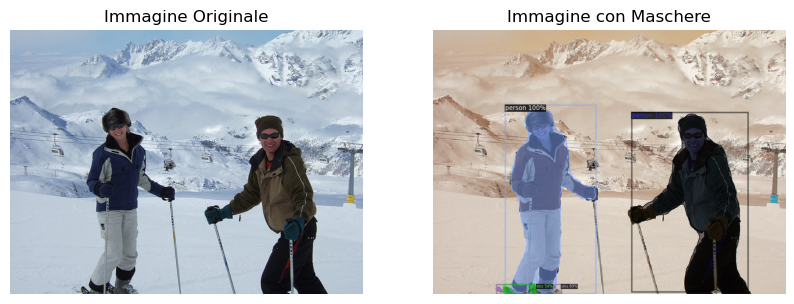

{'category_name': 'person', 'pixels': [[[191, 143], [190, 144], [189, 144], [188, 145], [186, 145], [184, 147], [183, 147], [182, 148], [180, 148], [179, 149], [176, 149], [175, 150], [174, 150], [172, 152], [172, 153], [171, 154], [171, 155], [170, 156], [170, 158], [169, 159], [169, 160], [168, 161], [168, 163], [167, 164], [167, 171], [168, 172], [168, 174], [169, 175], [169, 176], [170, 177], [170, 180], [171, 181], [171, 185], [172, 186], [172, 189], [173, 190], [173, 193], [172, 194], [172, 195], [171, 196], [171, 198], [170, 199], [170, 200], [169, 201], [169, 202], [168, 203], [168, 204], [162, 210], [161, 210], [156, 215], [156, 216], [155, 217], [155, 219], [153, 221], [153, 222], [152, 223], [152, 224], [150, 226], [150, 228], [149, 229], [149, 233], [148, 234], [148, 239], [147, 240], [147, 243], [146, 244], [146, 246], [145, 247], [145, 248], [144, 249], [144, 251], [143, 252], [143, 257], [142, 258], [142, 264], [141, 265], [141, 275], [140, 276], [140, 277], [141, 278], 

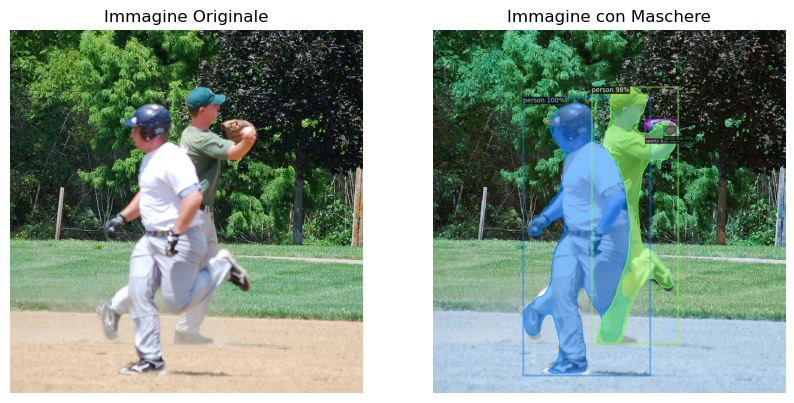

{'category_name': 'person', 'pixels': [[[248, 128], [246, 130], [245, 130], [244, 131], [242, 131], [240, 133], [239, 133], [238, 134], [237, 134], [236, 135], [234, 135], [233, 136], [230, 136], [229, 137], [225, 137], [223, 139], [222, 139], [217, 144], [217, 145], [216, 146], [216, 147], [214, 149], [214, 150], [206, 158], [206, 159], [205, 160], [205, 161], [204, 162], [204, 165], [205, 166], [205, 172], [206, 173], [206, 179], [207, 180], [207, 182], [208, 183], [208, 184], [209, 185], [209, 186], [210, 187], [210, 188], [213, 191], [213, 192], [215, 194], [215, 195], [216, 196], [216, 197], [217, 198], [217, 199], [219, 201], [219, 202], [221, 204], [221, 205], [226, 210], [226, 211], [227, 212], [227, 213], [228, 214], [228, 217], [229, 218], [229, 229], [230, 230], [230, 236], [229, 237], [229, 249], [228, 250], [228, 258], [227, 259], [227, 265], [226, 266], [226, 269], [225, 270], [225, 272], [224, 273], [224, 276], [223, 277], [223, 279], [222, 280], [222, 284], [221, 285], 

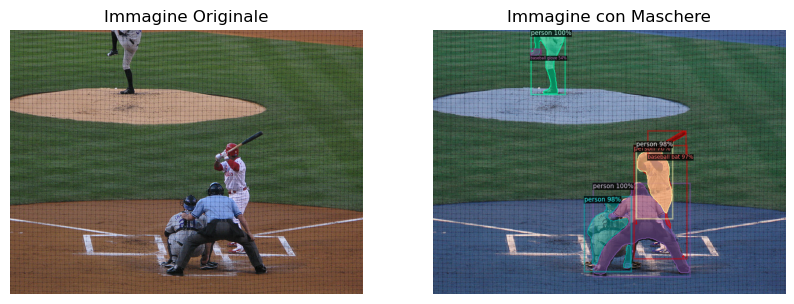

{'category_name': 'person', 'pixels': [[[368, 432]], [[349, 424], [349, 426], [348, 427], [348, 432], [349, 433], [353, 433], [354, 432], [356, 432], [361, 427], [360, 426], [359, 426], [358, 425], [357, 425], [356, 424]], [[361, 400], [361, 404], [362, 403], [362, 402], [361, 401]], [[366, 280], [365, 281], [364, 281], [363, 282], [362, 282], [361, 283], [361, 284], [360, 285], [360, 287], [359, 288], [359, 298], [358, 299], [358, 300], [349, 309], [348, 309], [347, 310], [346, 310], [345, 311], [344, 311], [343, 312], [342, 312], [342, 313], [339, 316], [338, 316], [336, 318], [335, 318], [335, 319], [334, 320], [334, 321], [332, 323], [332, 324], [327, 329], [326, 329], [325, 330], [324, 330], [324, 331], [322, 333], [322, 335], [321, 336], [322, 337], [322, 338], [324, 340], [326, 340], [327, 339], [349, 339], [350, 340], [352, 340], [353, 341], [354, 341], [355, 342], [355, 346], [356, 347], [356, 348], [355, 349], [355, 350], [354, 351], [354, 353], [353, 354], [353, 355], [349, 

In [81]:
boxes_predected = np.array([])
for image_filename in image_filenames:
    prediction = process_detectron2_output(image_filename, image_folder, MODEL_USED)
    boxes_predected = np.append(boxes_predected, prediction)


### Calcolo del root min square error

$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( (x_i^{\text{pred}} - x_i^{\text{gt}})^2 + (y_i^{\text{pred}} - y_i^{\text{gt}})^2 \right)}




1.	Confrontare maschere binarie: Per ogni istanza, devi confrontare la maschera predetta con quella di verità a terra.
2.	Calcolare la differenza: Sottrarre la maschera predetta dalla maschera di verità a terra.
3.	Calcolare il quadrato delle differenze: Elevare al quadrato la differenza di ogni pixel.
4.	Media degli errori: Calcolare la media degli errori quadratici.
5.	Radice quadrata della media: Calcolare la radice quadrata per ottenere il RMSE.


In [82]:
# Funzione per calcolare l'errore quadratico medio (RMSE)

def calculate_rmse(predicted_instances, gt_instances, min_overlap=0.0):
    """
    Calcola l'errore RMSE tra le segmentazioni predette e le segmentazioni di verità a terra per ogni istanza,
    considerando solo le istanze della stessa categoria e con una sovrapposizione sufficiente tra le maschere.
    
    :param predicted_instances: Array con le segmentazioni predette
    :param gt_instances: Array con le segmentazioni di verità a terra
    :param min_overlap: La percentuale minima di sovrapposizione tra le istanze (default 0.5)
    
    :return: Array con gli errori RMSE per ogni istanza e la media degli errori
    """
    
    errors = []
    
    # Itera attraverso le istanze predette e le GT
    for predicted, gt in zip(predicted_instances, gt_instances):
        # Verifica che le categorie siano le stesse
        if predicted['category_name'] != gt['category_name']:
            continue  # Se le categorie non sono uguali, salta l'istanza
        
        # Estrai le segmentazioni binarie per la predizione e la GT (in formato maschera)
        pred_mask = np.array(predicted["pixels"], dtype=np.uint8)
        gt_mask = np.array(gt["pixels"], dtype=np.uint8)
        
        # Calcolare la sovrapposizione tra le maschere (intersezione/union)
        intersection = np.sum(np.logical_and(pred_mask, gt_mask))
        union = np.sum(np.logical_or(pred_mask, gt_mask))
        overlap = intersection / float(union) if union > 0 else 0
        
        # Se la sovrapposizione è inferiore alla soglia minima, ignora questa coppia
        if overlap <= min_overlap:
            continue
        
        # Calcolare il RMSE (radice quadrata della media dei quadrati delle differenze)
        
        # Calcola le differenze quadrate tra i dati
        differences = pred_mask - gt_mask
        squared_diff = differences**2

        # Somma delle differenze quadrate
        sum_squared_diff = np.sum(squared_diff)

        # Calcola RMSE
        rmse = np.sqrt(sum_squared_diff / len(pred_mask))
        errors.append(rmse)
    
    # Calcolare la media degli errori RMSE
    if errors:
        mean_rmse = np.mean(errors)
    else:
        mean_rmse = 0  # Nessun errore se non ci sono istanze valide

    return errors, mean_rmse

## Calcolo degli errori

In [89]:
# Funzione per associare le predicted boxes alle GT boxes e calcolare gli errori

print("PREDIZIONI\n",boxes_predected)
print("GT:\n",gt_instances)


PREDIZIONI
 [{'category_name': 'person', 'pixels': [[[191, 143], [190, 144], [189, 144], [188, 145], [186, 145], [184, 147], [183, 147], [182, 148], [180, 148], [179, 149], [176, 149], [175, 150], [174, 150], [172, 152], [172, 153], [171, 154], [171, 155], [170, 156], [170, 158], [169, 159], [169, 160], [168, 161], [168, 163], [167, 164], [167, 171], [168, 172], [168, 174], [169, 175], [169, 176], [170, 177], [170, 180], [171, 181], [171, 185], [172, 186], [172, 189], [173, 190], [173, 193], [172, 194], [172, 195], [171, 196], [171, 198], [170, 199], [170, 200], [169, 201], [169, 202], [168, 203], [168, 204], [162, 210], [161, 210], [156, 215], [156, 216], [155, 217], [155, 219], [153, 221], [153, 222], [152, 223], [152, 224], [150, 226], [150, 228], [149, 229], [149, 233], [148, 234], [148, 239], [147, 240], [147, 243], [146, 244], [146, 246], [145, 247], [145, 248], [144, 249], [144, 251], [143, 252], [143, 257], [142, 258], [142, 264], [141, 265], [141, 275], [140, 276], [140, 277],